<a href="https://colab.research.google.com/github/Manav010203/Quiz/blob/cloudmain/sign_lang.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import requests
import zipfile
from pathlib import Path

# setup path to data folder
data_path = Path("data/")
image_path =data_path / "sign-language"

#if the image folder doesn't exist, download it and prepare it...
if image_path.is_dir():
  print(f"{image_path} directory exists")
else:
  print(f"{image_path} doenot exist,creating one ...")
  image_path.mkdir(parents=True,exist_ok=True)

  #download pizza, steak and sushi data
  with open(data_path/"sign-lang.zip","wb") as f:
    requests=requests.get("https://github.com/Manav010203/hand-sign/raw/refs/heads/cloudmain/archive%20(4).zip")
    print("Downloading data..")
    f.write(requests.content)

  #unzip file
  with zipfile.ZipFile(data_path/"sign-lang.zip","r") as zip_ref:
    print("unzippind data...")
    zip_ref.extractall(image_path)

data/sign-language doenot exist,creating one ...
unzippind data...


In [2]:
import os
def walk_through_dir(dir_path):
  """walks thorgh dir_path returning its contents..."""
  for dirpath,dirnames,filenames in os.walk(dir_path):
    print(f"there are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'")


In [3]:
walk_through_dir(image_path)

there are 1 directories and 0 images in 'data/sign-language'
there are 2 directories and 0 images in 'data/sign-language/ASL_Gestures_36_Classes'
there are 36 directories and 0 images in 'data/sign-language/ASL_Gestures_36_Classes/test'
there are 0 directories and 14 images in 'data/sign-language/ASL_Gestures_36_Classes/test/5'
there are 0 directories and 14 images in 'data/sign-language/ASL_Gestures_36_Classes/test/c'
there are 0 directories and 14 images in 'data/sign-language/ASL_Gestures_36_Classes/test/3'
there are 0 directories and 14 images in 'data/sign-language/ASL_Gestures_36_Classes/test/d'
there are 0 directories and 14 images in 'data/sign-language/ASL_Gestures_36_Classes/test/g'
there are 0 directories and 14 images in 'data/sign-language/ASL_Gestures_36_Classes/test/b'
there are 0 directories and 14 images in 'data/sign-language/ASL_Gestures_36_Classes/test/4'
there are 0 directories and 14 images in 'data/sign-language/ASL_Gestures_36_Classes/test/a'
there are 0 directo

In [4]:
train_data_path = image_path / "ASL_Gestures_36_Classes" / "train"
test_data_path = image_path / "ASL_Gestures_36_Classes" / "test"

In [5]:
train_data_path,test_data_path

(PosixPath('data/sign-language/ASL_Gestures_36_Classes/train'),
 PosixPath('data/sign-language/ASL_Gestures_36_Classes/test'))

In [6]:
image_path_list = list[image_path.glob("*/*/*/*/*.jpeg")]

data/sign-language/ASL_Gestures_36_Classes/train/9/hand1_9_dif_seg_5_cropped.jpeg
9
random image path:data/sign-language/ASL_Gestures_36_Classes/train/9/hand1_9_dif_seg_5_cropped.jpeg
Image class:9
Image height:400
Image width:400


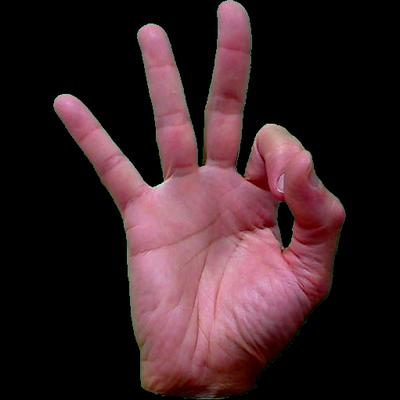

In [7]:
import random
from PIL import Image

# random.seed(42)

#1. Get all image paths
image_path_list=list(image_path.glob("*/*/*/*.jpeg"))
# image_path_list

#2 pick a random image path

random_imag_path = random.choice(image_path_list)
print(random_imag_path)

#3 Get image class from path name (the image class is the name of the directory where the image is stored)
image_class = random_imag_path.parent.stem
print(image_class)

#4 open image
img =Image.open(random_imag_path)

#5 print metadata
print(f"random image path:{random_imag_path}")
print(f"Image class:{image_class}")
print(f"Image height:{img.height}")
print(f"Image width:{img.width}")
img

Text(0.5, 1.0, 'image clas :9 | image shape :(400, 400, 3) ')

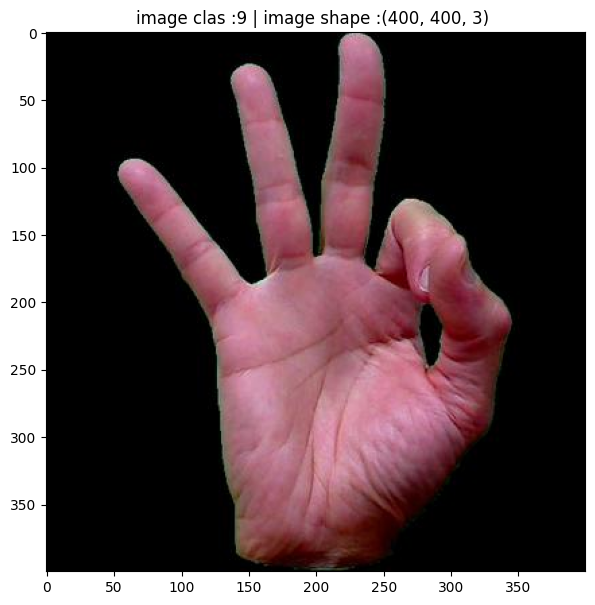

In [8]:
import matplotlib.pyplot as plt
import numpy as np
# trun image into array
imag_as_arr = np.asarray(img)
# imag_as_arr.shape


# plt.imshow(img)
plt.figure(figsize=(10,7))
plt.imshow(imag_as_arr)
plt.title(f"image clas :{image_class} | image shape :{imag_as_arr.shape} ")

In [9]:
from torchvision import transforms
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [10]:
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_data_path,
                                  transform=transform)
test_data = datasets.ImageFolder(root=test_data_path,
                                 transform=transform)
print(f"Train data:\n{train_data}\nTest data:\n{test_data}")

Train data:
Dataset ImageFolder
    Number of datapoints: 2011
    Root location: data/sign-language/ASL_Gestures_36_Classes/train
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )
Test data:
Dataset ImageFolder
    Number of datapoints: 504
    Root location: data/sign-language/ASL_Gestures_36_Classes/test
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )


In [11]:
class_name = train_data.classes
class_name

['0',
 '1',
 '2',
 '3',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 'a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z']

In [12]:
len(train_data),len(test_data)

(2011, 504)

In [13]:
train_data.samples[0]

('data/sign-language/ASL_Gestures_36_Classes/train/0/hand1_0_bot_seg_1_cropped.jpeg',
 0)

In [14]:
img,label = train_data[77][0],train_data[77][1]
print(f"image shape:{img.shape}")
print(f"label:{label}")
print(f"dtyep:{img.dtype}")

image shape:torch.Size([3, 224, 224])
label:1
dtyep:torch.float32


In [15]:
size_transform = transforms.Resize((224,224))

In [16]:
img_permute =img.permute(1,2,0)
img_permute.shape
# class_name[label]

torch.Size([224, 224, 3])

In [17]:
from torch.utils.data import DataLoader
train_data_dataloader = DataLoader(train_data,batch_size=32,shuffle=True,num_workers=2)
test_data_dataloader = DataLoader(test_data,batch_size=32,shuffle=True,num_workers=2)
train_data_dataloader,test_data_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7cbb8d2f2850>,
 <torch.utils.data.dataloader.DataLoader at 0x7cbb8d462210>)

In [18]:
import torch
from torch import nn
device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cpu'

In [19]:
class Sign_lang(nn.Module):
  def __init__(self,
               input_shape:int,
               out_shape:int,
               hidden_unit:int):
    super().__init__()
    self.Conv_layer_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                                  out_channels=hidden_unit,
                                  kernel_size=3,
                                  stride =1,
                                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_unit,
                                  out_channels=hidden_unit,
                                  kernel_size=3,
                                  stride =1,
                                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                                  stride=2)
        )
    self.Conv_layer_2=nn.Sequential(
        nn.Conv2d(in_channels=hidden_unit,
                  out_channels=hidden_unit,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_unit,
                  out_channels=hidden_unit,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.MaxPool2d(kernel_size=2,
                    stride=2)
    )
    self.clasifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_unit*56*56,
                  out_features=out_shape)
    )
  def forward(self,x):
    x=self.Conv_layer_1(x)
    x=self.Conv_layer_2(x)
    x=self.clasifier(x)
    return x


In [20]:
model_0 = Sign_lang(input_shape=3,
                    out_shape=len(class_name),
                    hidden_unit=10)

In [21]:
image_batch,label = next(iter(train_data_dataloader))
image_batch.shape,label.shape

(torch.Size([32, 3, 224, 224]), torch.Size([32]))

In [22]:
model_0(image_batch)

tensor([[-0.0560,  0.0017,  0.0044,  ..., -0.0187,  0.0005, -0.0031],
        [-0.0563,  0.0004,  0.0071,  ..., -0.0087, -0.0039, -0.0020],
        [-0.0593,  0.0006,  0.0007,  ..., -0.0079, -0.0048, -0.0036],
        ...,
        [-0.0581, -0.0002,  0.0040,  ..., -0.0129, -0.0029, -0.0032],
        [-0.0551, -0.0009,  0.0056,  ..., -0.0152, -0.0026, -0.0034],
        [-0.0595, -0.0011,  0.0032,  ..., -0.0156,  0.0024,  0.0023]],
       grad_fn=<AddmmBackward0>)

In [23]:
#training step
def train_step(model:nn.Module,
                dataloader: torch.utils.data.DataLoader,
                loss_fn,
                optimizer,

                device):
  model.train()
  train_loss ,train_acc = 0,0
  for batch,(X,y) in enumerate(dataloader):
    X,y = X.to(device),y.to(device)

    #1 forward pass
    y_logits = model(X)
    y_pred=y_logits.argmax(dim=1)

    #2 loss
    loss = loss_fn (y_logits,y)
    train_loss+=loss.item()
    train_acc += ((y_pred == y).sum().item()/len(y_pred))

    #3 zero grad
    optimizer.zero_grad()

    #4 loss backward
    loss.backward()

    #5 optimizeer
    optimizer.step()

  train_loss /= len(dataloader)
  train_acc /= len(dataloader)


  return train_loss,train_acc


In [24]:
# testing step
def test_step(model:nn.Module,
              dataloader:torch.utils.data.DataLoader,
              loss_fn,

              device):
  model.eval()
  test_loss,test_acc = 0,0
  with torch.inference_mode():
    for batch,(X,y) in enumerate(dataloader):
      X,y = X.to(device),y.to(device)
      y_logit = model(X)
      loss = loss_fn(y_logit,y)
      test_loss+= loss.item()
       # Calculate and accumulate accuracy
      test_pred_labels = y_logit.argmax(dim=1)
      test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))
    test_loss /= len(dataloader)
    test_acc /= len(dataloader)
  return test_loss,test_acc

In [25]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(),
                             lr=0.001)

In [26]:
from tqdm.auto import tqdm
from timeit import default_timer as timer
start_time = timer()
epochs = 3
for epoch in tqdm(range(epochs)):
  train_loss,train_acc = train_step(model=model_0,
             dataloader=train_data_dataloader,
             loss_fn=loss_fn,
             optimizer=optimizer,
             device=device)
  test_loss,test_acc = test_step(model=model_0,
            dataloader=test_data_dataloader,
            loss_fn=loss_fn,
            device=device
             )
  print(f"Epoch:{epoch} |train_loss:{train_loss:.4f} | train acc:{train_acc:.4f} | test loss :{test_loss:.4f} | test acc:{test_acc:.4f}")

end_time = timer()
print(f"total training time:{end_time-start_time}")

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch:0 |train_loss:1.6111 | train acc:0.5784 | test loss :0.5293 | test acc:0.8340
Epoch:1 |train_loss:0.3264 | train acc:0.8932 | test loss :0.2988 | test acc:0.9004
Epoch:2 |train_loss:0.1745 | train acc:0.9408 | test loss :0.1859 | test acc:0.9453
total training time:404.81530620200004


In [27]:
#save model
from pathlib import Path
model_path = Path("model")
model_path.mkdir(parents=True,exist_ok=True)
model_name = "sign-lan-model_0"
model_save_path = model_path / model_name
print(model_save_path)


model/sign-lan-model_0


In [28]:
torch.save(obj=model_0.state_dict(),
           f=model_save_path)